## **Deep Learning based Antimicrobial Susceptibility Phenotyping Detection**

Dataset Link: https://ora.ox.ac.uk/objects/uuid:12153432-e8b3-4398-a395-abfb980bd84e

#### **Libraries**

In [1]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Count of Images from each folder**

In [2]:
raw_parent_dir = "Zagajewski_Data/Data/MG1655/All_images"
folder_names = ['WT+ETOH', 'CIP+ETOH', 'GENT+ETOH', 'RIF+ETOH']
for f in folder_names:
    old_name = os.path.join(raw_parent_dir, f)
    new_name = os.path.join(raw_parent_dir, f.split("+")[0])
    os.rename(old_name, new_name)
    count_of_images = len(os.listdir(os.path.join(raw_parent_dir, f.split("+")[0])))
    print(f"{new_name} has {count_of_images} images")

Zagajewski_Data/Data/MG1655/All_images\WT has 455 images
Zagajewski_Data/Data/MG1655/All_images\CIP has 285 images
Zagajewski_Data/Data/MG1655/All_images\GENT has 199 images
Zagajewski_Data/Data/MG1655/All_images\RIF has 279 images


#### **Complete Data about the tif file**

In [3]:
from PIL import Image
import tifffile

# Path to one image
main_path = os.path.join(raw_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
img_path = os.path.join(main_path, img_name)

print("Image Path:", img_path)
print("-"*50)

img_pil = Image.open(img_path)

img_array = np.array(img_pil)

print("\nNumPy Information")
print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)

with tifffile.TiffFile(img_path) as tif:
    print("\nTIFF Metadata")
    print("Image shape:", tif.pages[0].shape)
    print("Image dtype:", tif.pages[0].dtype)

Image Path: Zagajewski_Data/Data/MG1655/All_images\WT/200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY0.tif
--------------------------------------------------

NumPy Information
Shape: (684, 420, 3)
Data type: uint8

TIFF Metadata
Image shape: (3, 684, 420)
Image dtype: uint16


#### **Sample image from Each Type**

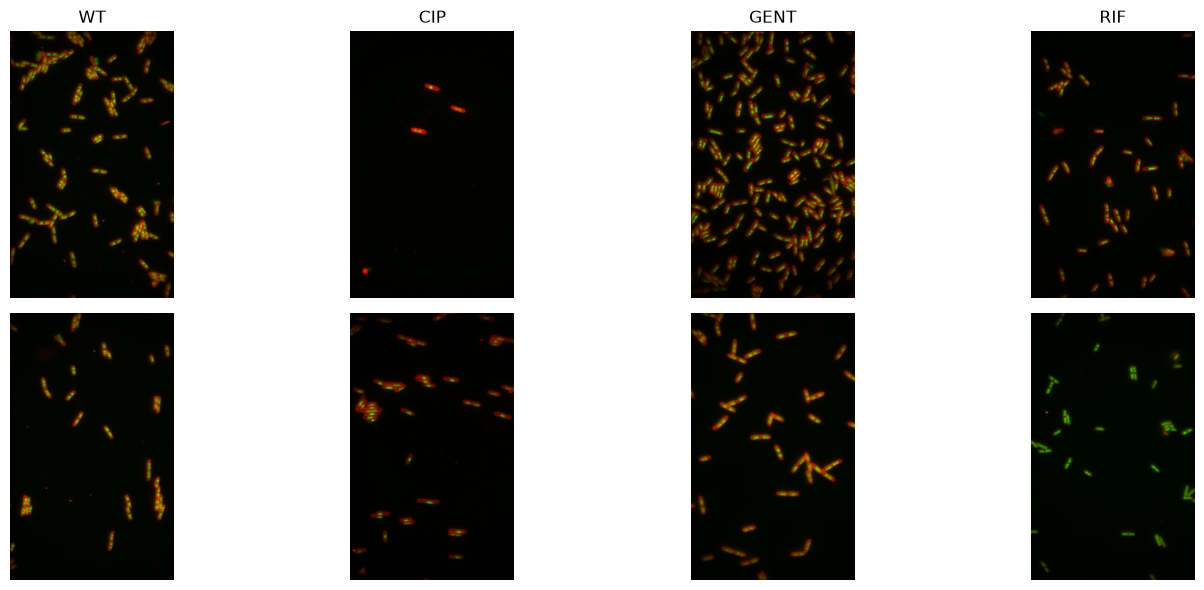

In [4]:
import random

base_path = raw_parent_dir
classes = ["WT", "CIP", "GENT", "RIF"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 6))

for col, cls in enumerate(classes):

    class_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]

    selected = random.sample(images, 2)

    for row in range(2):

        img_path = os.path.join(class_path, selected[row])
        img = tifffile.imread(img_path)
        # (3, H, W) → (H, W, 3)
        img = np.transpose(img, (1, 2, 0))
        # Normalize safely
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        # Add class title only on top row
        if row == 0:
            axes[row, col].set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()

#### **Data Split**

In [5]:
# Paths
source_dir = raw_parent_dir
target_dir = "intermediate"

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


#### **Data After Train, Test and Validation split**

In [6]:
train_parent_dir = r"intermediate/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
WT has 318 images
CIP has 199 images
GENT has 139 images
RIF has 195 images


In [7]:
val_parent_dir = "intermediate/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
WT has 68 images
CIP has 42 images
GENT has 29 images
RIF has 41 images


In [8]:
test_parent_dir = "intermediate/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
WT has 69 images
CIP has 44 images
GENT has 31 images
RIF has 43 images
